In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing / model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# Evaluation metric (matches this competition exactly)
from sklearn.metrics import roc_auc_score, roc_curve

# Misc
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load training data
train = pd.read_csv('C:\\Users\\leona\\Documents\\Kaggle Competition\\Kaggle_competition\\Train_test_data\\Smartphone_addiction\\train.csv')

# Quick overview of the data

print(train.shape)
print(train.dtypes)
print(train.isnull().sum())
print(train.head())
train.describe()

(691369, 14)
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
academic_work_impact           str
addicted_label               int64
dtype: object
id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: 

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [3]:
# Remove id column
train.drop('id', axis=1, inplace=True)

categorical_cols = train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Treat addicted_label as categorical for plotting even though it's int (0/1)
if "addicted_label" in numeric_cols:
    numeric_cols.remove("addicted_label")
    categorical_cols.append("addicted_label")

numeric_cols = [c for c in numeric_cols if c.lower() != "id"]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'stress_level', 'academic_work_impact', 'addicted_label']
Numeric columns: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']


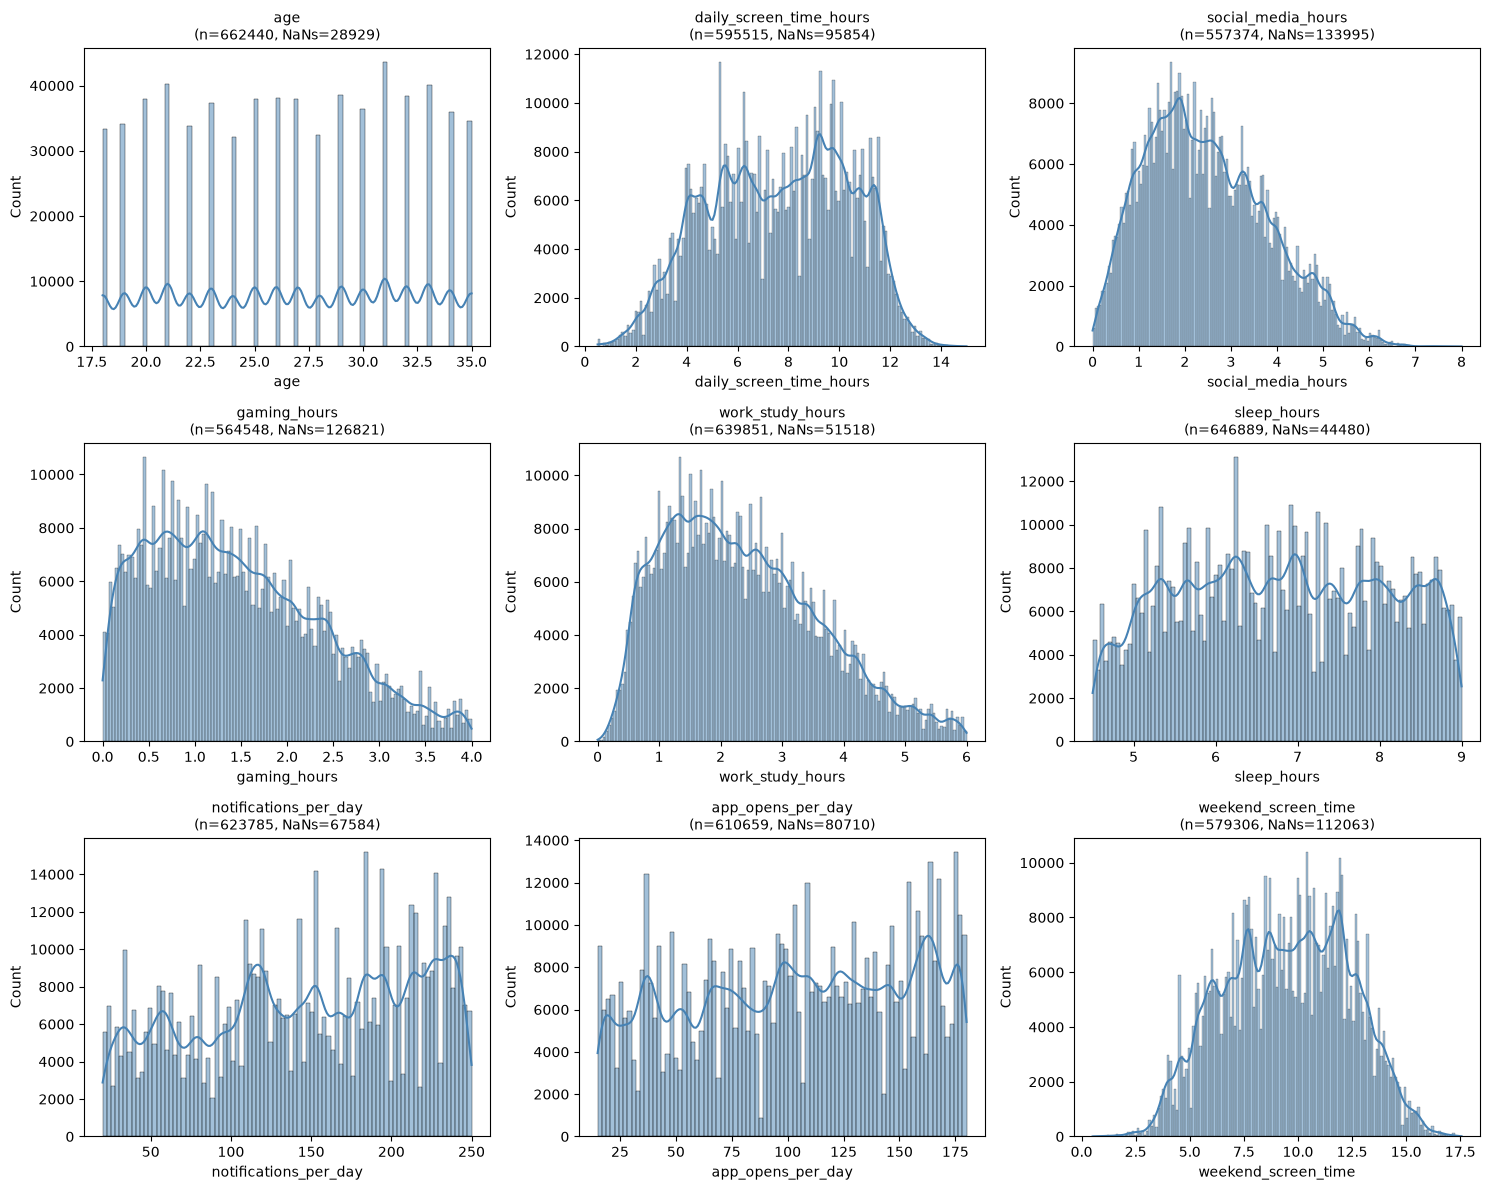

In [4]:
# --- Distributions for numeric variables (NaNs excluded, count shown in title) ---
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = train[col].dropna()
    nan_count = train[col].isna().sum()

    sns.histplot(data, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col}\n(n={len(data)}, NaNs={nan_count})", fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

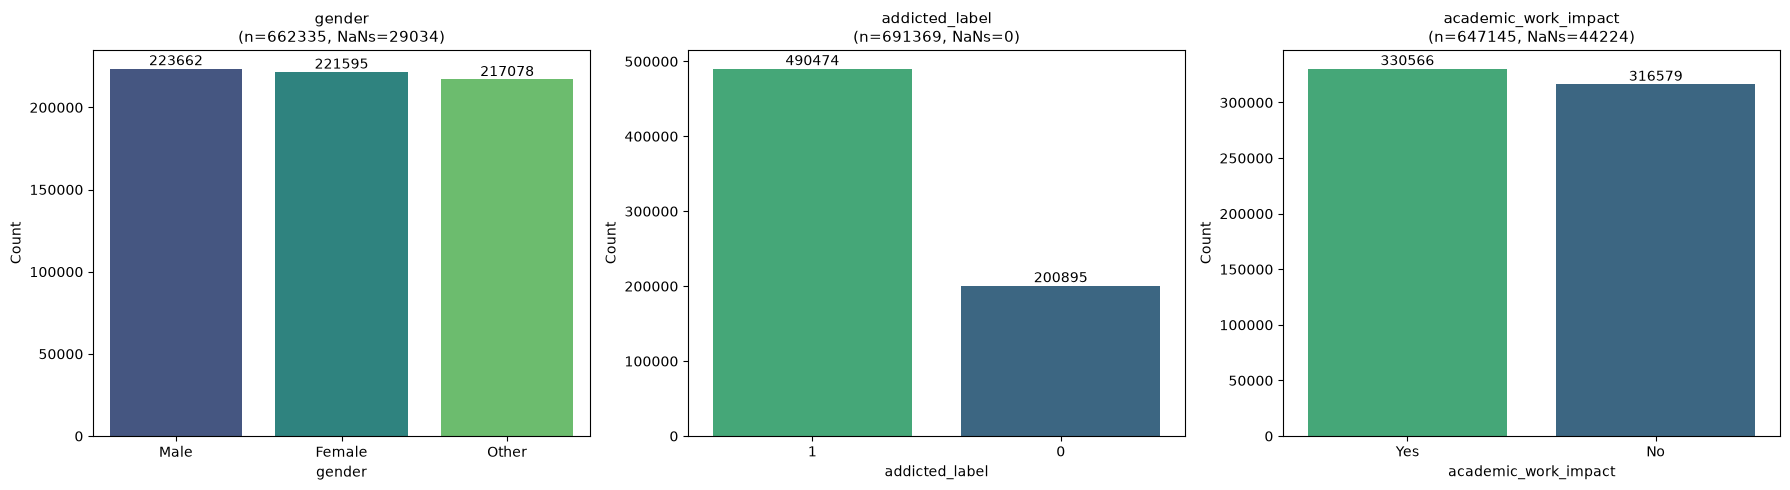

In [5]:
# --- Bar plots for categorical variables (gender, addicted_label), NaNs excluded but counted ---
plot_cols = ["gender", "addicted_label","academic_work_impact"]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(6 * len(plot_cols), 5))
if len(plot_cols) == 1:
    axes = [axes]

for i, col in enumerate(plot_cols):
    data = train[col].dropna()
    nan_count = train[col].isna().sum()

    sns.countplot(x=data, ax=axes[i], hue=data, palette="viridis", legend=False,
                  order=data.value_counts().index)
    axes[i].set_title(f"{col}\n(n={len(data)}, NaNs={nan_count})", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    for container in axes[i].containers:
        axes[i].bar_label(container)

plt.tight_layout()
plt.show()

In [ ]:
# Train test split for training data (Addicted label is the target variable)
categorical_cols = train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
for col in categorical_cols:
    train[col] = train[col].astype("category")
X = train.drop("addicted_label", axis=1)
y = train["addicted_label"]
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=5,
    stratify=y
)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")
print(f"Train target balance:\n{y_train.value_counts(normalize=True)}")

Train shape: (553095, 12), Val shape: (138274, 12)
Train target balance:
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


In [8]:
# Trying new package lazypredict for baseline model comparison
# Lazypredict automatically handels missing values with SKlearn's SimpleImputer, so we don't need to do any preprocessing for this baseline comparison.
import lazypredict
from lazypredict import LazyClassifier
from lazypredict.Supervised import CLASSIFIERS

exclude = {"SVC", "NuSVC", "StackingClassifier", "LabelPropagation", "LabelSpreading"} # excluding slow classifiers for large datasets
classifiers = [cls for name, cls in CLASSIFIERS if name not in exclude]
clf = LazyClassifier(verbose=1, ignore_warnings=True, custom_metric=None,classifiers=classifiers) 
models, predictions = clf.fit(X_train, X_val, y_train, y_val)
print(models)

Large dataset detected (553095 samples). Training all models may take a long time. Consider using a subset or setting max_models/timeout.


  0%|          | 0/27 [00:00<?, ?it/s]

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
XGBClassifier                  0.895136           0.869056  0.959389   
LGBMClassifier                 0.887123           0.860131  0.953572   
RandomForestClassifier         0.868117           0.833232  0.940626   
NearestCentroid                0.822939           0.832322  0.902963   
ExtraTreesClassifier           0.865333           0.829727  0.938630   
BaggingClassifier              0.853935           0.829643  0.922914   
GaussianNB                     0.828406           0.817705  0.900076   
AdaBoostClassifier             0.833316           0.806669  0.914562   
BernoulliNB                    0.797127           0.801229  0.869585   
QuadraticDiscriminantAnalysis  0.824457           0.796531  0.896381   
KNeighborsClassifier           0.834987           0.793270  0.891520   
LinearDiscriminantAnalysis     0.832550           0.784558  0.90

In [13]:
# As XGB did best, we will continue with XGB and try to improve it with hyperparameter tuning. 
# Optuna will be used instead of GridSearchCV or RandomizedSearchCV as it is more efficient and can find better hyperparameters in less time with large datasets
import optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    model = xgb.XGBClassifier(**params, random_state=5, n_jobs=-1,enable_categorical=True, tree_method="hist", eval_metric="auc")
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_val)[:, 1]  # adjust for multiclass
    return roc_auc_score(y_val, preds)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)
print(study.best_params)

[I 2026-08-27 11:29:54,127] A new study created in memory with name: no-name-df5d8098-850f-4066-854d-c994f8a8724c
[I 2026-08-27 11:30:08,117] Trial 0 finished with value: 0.9632219304772518 and parameters: {'n_estimators': 782, 'max_depth': 5, 'learning_rate': 0.20920058404559436, 'subsample': 0.9849328091894949, 'colsample_bytree': 0.5552363347431, 'min_child_weight': 5, 'reg_alpha': 2.7710073308601786e-07, 'reg_lambda': 2.9119080151093663e-06}. Best is trial 0 with value: 0.9632219304772518.
[I 2026-08-27 11:30:22,339] Trial 1 finished with value: 0.9565715531665961 and parameters: {'n_estimators': 859, 'max_depth': 4, 'learning_rate': 0.04659693522201078, 'subsample': 0.6025770607435404, 'colsample_bytree': 0.5729133712399546, 'min_child_weight': 1, 'reg_alpha': 0.00011542437787654125, 'reg_lambda': 0.7277543324853532}. Best is trial 0 with value: 0.9632219304772518.
[I 2026-08-27 11:31:03,719] Trial 2 finished with value: 0.9618597488050953 and parameters: {'n_estimators': 916, 'ma

{'n_estimators': 963, 'max_depth': 5, 'learning_rate': 0.1294876490893459, 'subsample': 0.9051062510569949, 'colsample_bytree': 0.9723334921499867, 'min_child_weight': 1, 'reg_alpha': 2.4385707346136605, 'reg_lambda': 1.9557331266986029}


In [ ]:
best_params = study.best_params
model = xgb.XGBClassifier(
    **best_params,
    random_state=5,
    n_jobs=-1,
    enable_categorical=True,
    tree_method="hist",
    eval_metric="auc",
)
model.fit(X_train, y_train)
val_preds_proba = model.predict_proba(X_val)[:, 1]
val_preds_label = model.predict(X_val)

# AUC on validation set
val_auc = roc_auc_score(y_val, val_preds_proba)
print(f"Validation AUC: {val_auc:.4f}")

# Build an analysis dataframe: original features + true label + predictions
analysis_df = X_val.copy()
analysis_df['true_label'] = y_val.values
analysis_df['predicted_label'] = val_preds_label
analysis_df['predicted_proba'] = val_preds_proba
analysis_df['correct'] = analysis_df['true_label'] == analysis_df['predicted_label']

# Isolate misclassified rows
mistakes = analysis_df[~analysis_df['correct']].copy()
print(f"Total validation rows: {len(analysis_df)}")
print(f"Misclassified: {len(mistakes)} ({len(mistakes)/len(analysis_df):.2%})")

# Sort mistakes by how confidently wrong the model was (worst first)
mistakes['confidence_error'] = abs(mistakes['predicted_proba'] - mistakes['true_label'])
mistakes = mistakes.sort_values('confidence_error', ascending=False)

mistakes.head(20)


Validation AUC: 0.9635
Total validation rows: 138274
Misclassified: 13587 (9.83%)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,true_label,predicted_label,predicted_proba,correct,confidence_error
572236,32.0,9.62,3.02,NaN,2.53,6.12,110.0,71.0,14.71,Male,High,No,0,1,0.999893,False,0.999893
686716,NaN,10.64,2.63,2.42,5.33,8.12,106.0,104.0,12.51,Other,Low,No,0,1,0.999770,False,0.999770
638318,23.0,11.04,3.05,2.37,5.42,6.26,82.0,17.0,12.36,Female,Low,No,0,1,0.999613,False,0.999613
581413,20.0,9.29,4.35,NaN,1.87,8.96,104.0,30.0,10.61,Male,Low,Yes,0,1,0.999245,False,0.999245
474170,18.0,9.62,3.92,3.38,1.38,6.05,190.0,165.0,10.37,Male,High,Yes,0,1,0.999156,False,0.999156
678906,20.0,10.37,2.26,3.15,4.33,4.88,95.0,NaN,11.24,Other,Low,Yes,0,1,0.999129,False,0.999129
561712,25.0,10.10,1.47,0.44,NaN,8.79,142.0,85.0,11.38,Other,NaN,No,0,1,0.999100,False,0.999100
652587,23.0,9.28,2.19,3.05,1.37,8.32,132.0,155.0,15.24,Male,Low,No,0,1,0.999095,False,0.999095
435561,21.0,10.61,NaN,NaN,4.22,7.81,122.0,99.0,11.81,Female,High,Yes,0,1,0.999092,False,0.999092
1273,23.0,9.25,NaN,3.13,1.97,8.46,108.0,99.0,11.38,Female,Medium,NaN,0,1,0.998989,False,0.998989


In [23]:
# Train the final model on the full training data (train + validation) using the best hyperparameters found by Optuna
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])
model.fit(X_full, y_full)
model.save_model('C:\\Users\\leona\\Documents\\Kaggle Competition\\Kaggle_competition\\Models\\Smartphone_addiction\\xgb_first_model.json')
# later: model = xgb.XGBClassifier(); model.load_model('C:\\Users\\leona\\Documents\\Kaggle Competition\\Kaggle_competition\\Models\\Smartphone_addiction\\xgb_first_model.json')

In [21]:
# load first model 
model = model = xgb.XGBClassifier(); model.load_model('C:\\Users\\leona\\Documents\\Kaggle Competition\\Kaggle_competition\\Models\\Smartphone_addiction\\xgb_first_model.json')

In [ ]:
# --- Predictions for competition set ---
# Load test data
test = pd.read_csv('C:\\Users\\leona\\Documents\\Kaggle Competition\\Kaggle_competition\\Train_test_data\\Smartphone_addiction\\test.csv')
test_ids = test['id']
test.drop('id', axis=1, inplace=True)
assert list(test.columns) == list(X_train.columns), "Column mismatch between train and test!"
categorical_cols = test.select_dtypes(include=["object", "category", "string"]).columns.tolist()
for col in categorical_cols:
    test[col] = pd.Categorical(test[col], categories=X_train[col].cat.categories)

test_preds_proba = model.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    'id': test_ids,
    'addicted_label': test_preds_proba
})
submission.to_csv('C:\\Users\\leona\\Documents\\Kaggle Competition\\Kaggle_competition\\Submissions\\Smartphone_addiction\\submission1.csv', index=False)

# submission1 with xgb_first_model.json scored AUC 0.96542 and was ranked 1594 on leaderboard. Top score was 0.97189